<a href="https://colab.research.google.com/github/PedroHenriquesDev/Exercicios-Python/blob/main/Matplotlib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)


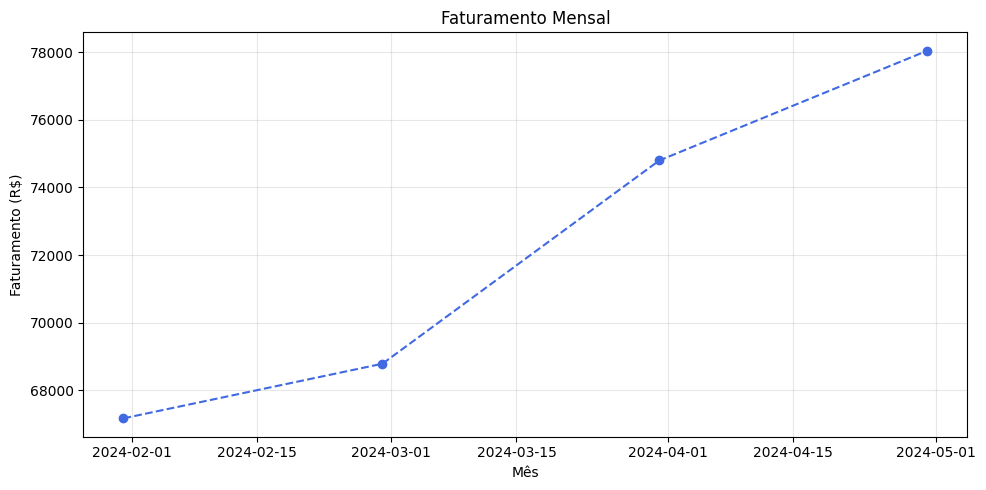

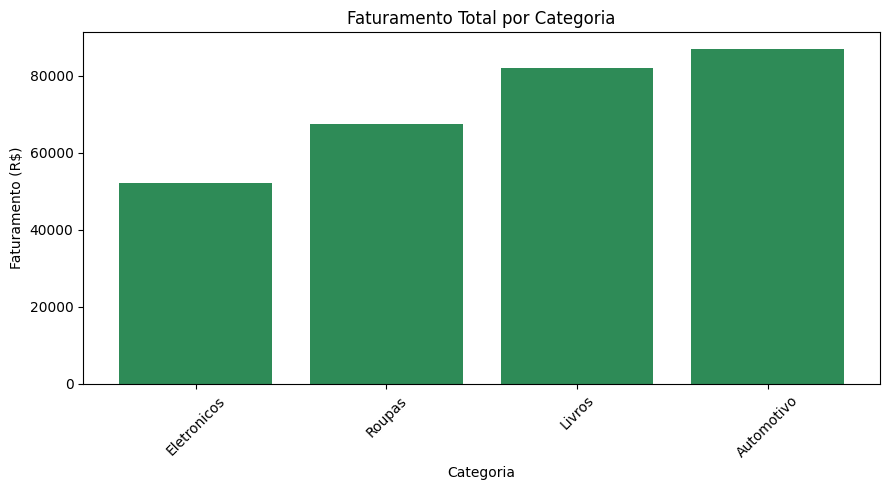

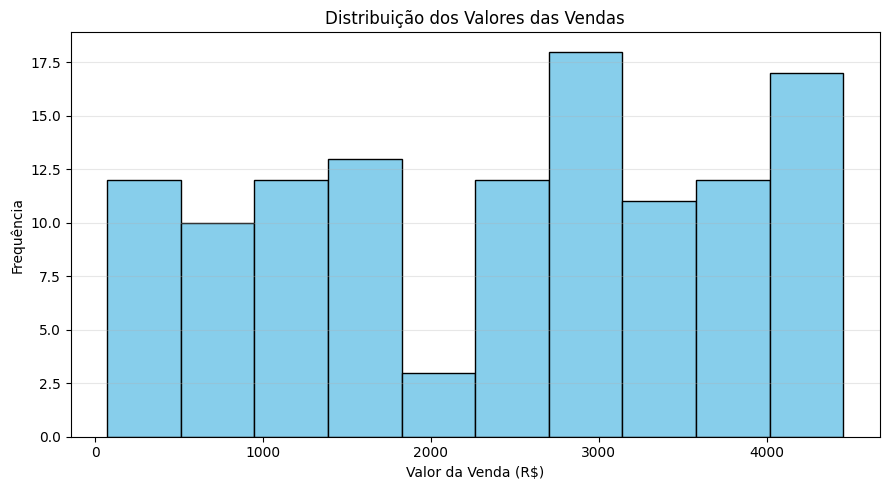

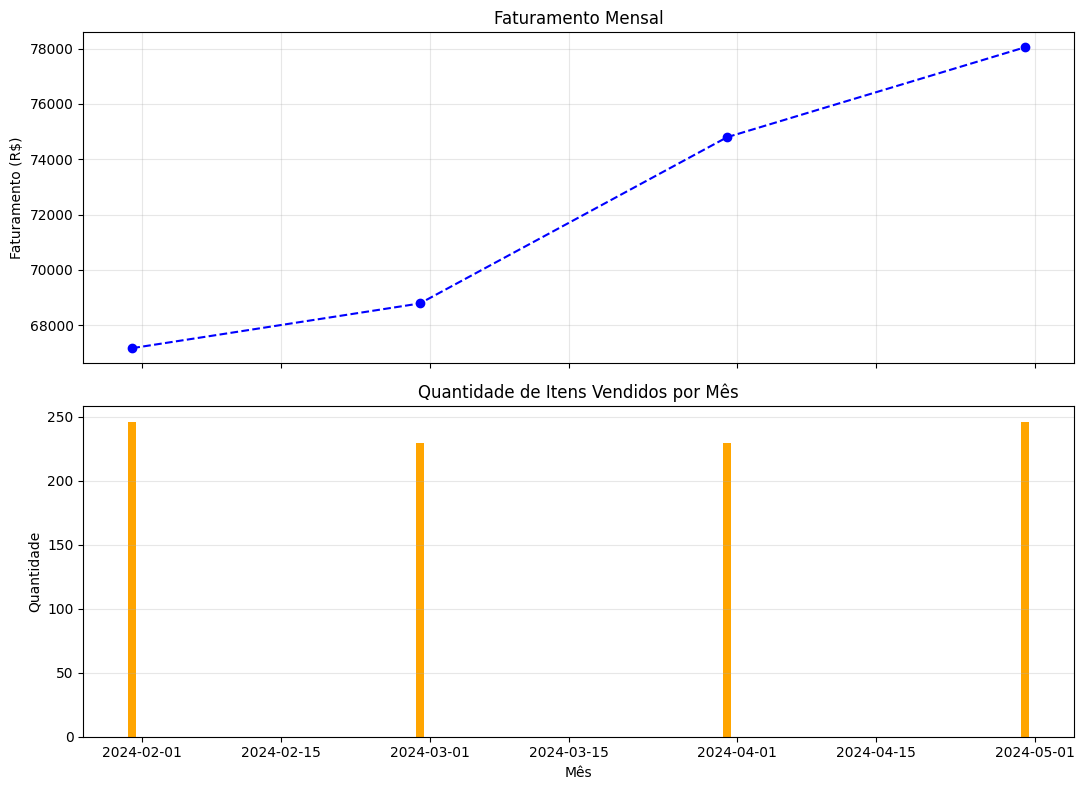

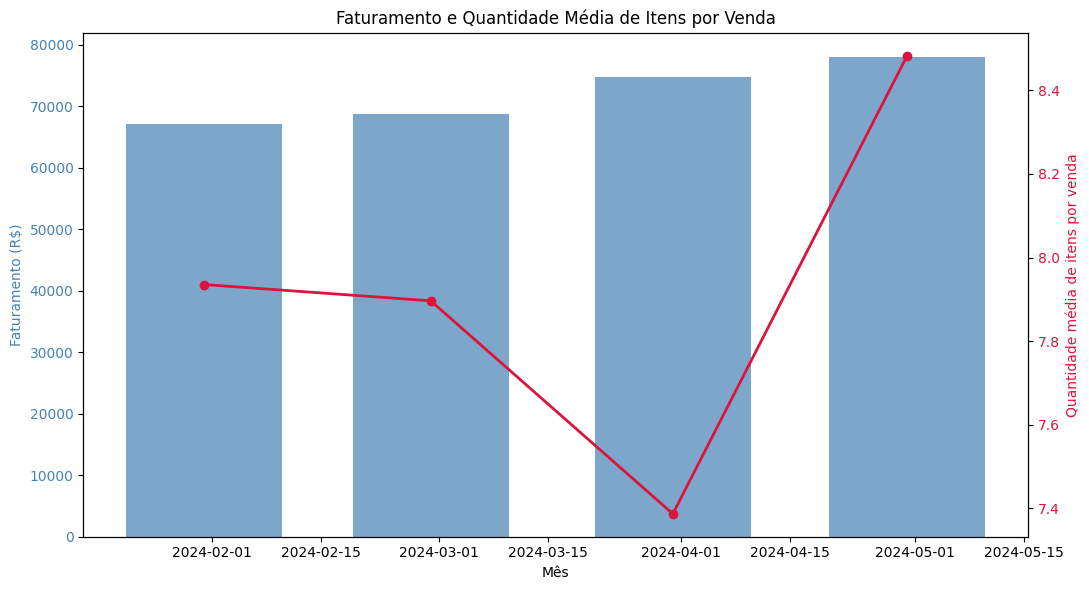

NameError: name 'faturamento' is not defined

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


faturamento_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

plt.figure(figsize=(10, 5))

plt.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='royalblue'
)

plt.title('Faturamento Mensal')
plt.xlabel('Mês')
plt.ylabel('Faturamento (R$)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



vendas_categoria = (
    df.groupby('categoria')['valor_venda']
      .sum()
      .sort_values()
)

plt.figure(figsize=(9, 5))

plt.bar(
    vendas_categoria.index,
    vendas_categoria.values,
    color='seagreen'
)

plt.title('Faturamento Total por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Faturamento (R$)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()




plt.figure(figsize=(9, 5))

plt.hist(
    df['valor'],
    bins=10,
    edgecolor='black',
    color='skyblue'
)

plt.title('Distribuição dos Valores das Vendas')
plt.xlabel('Valor da Venda (R$)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



faturamento_mensal = (
    df.set_index('data')['valor_venda']
      .resample('ME')
      .sum()
)

quantidade_mensal = (
    df.set_index('data')['quantidade']
      .resample('ME')
      .sum()
)

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True
)

ax1.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='blue'
)

ax1.set_title('Faturamento Mensal')
ax1.set_ylabel('Faturamento (R$)')
ax1.grid(True, alpha=0.3)



ax2.bar(
    quantidade_mensal.index,
    quantidade_mensal.values,
    color='orange'
)

ax2.set_title('Quantidade de Itens Vendidos por Mês')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Quantidade')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



quantidade_media_mensal = (
    df.set_index('data')['quantidade']
      .resample('ME')
      .mean()
)

fig, ax1 = plt.subplots(figsize=(11, 6))


ax1.bar(
    faturamento_mensal.index,
    faturamento_mensal.values,
    width=20,
    color='steelblue',
    alpha=0.7,
    label='Faturamento'
)

ax1.set_xlabel('Mês')
ax1.set_ylabel('Faturamento (R$)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')



ax2 = ax1.twinx()

ax2.plot(
    quantidade_media_mensal.index,
    quantidade_media_mensal.values,
    color='crimson',
    marker='o',
    linewidth=2,
    label='Quantidade média'
)

ax2.set_ylabel(
    'Quantidade média de itens por venda',
    color='crimson'
)

ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Faturamento e Quantidade Média de Itens por Venda')
fig.tight_layout()
plt.show()


faturamento


mes_maior = faturamento_mensal.idxmax()
maior_faturamento = faturamento_mensal.max()

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    faturamento_mensal.index,
    faturamento_mensal.values,
    marker='o',
    linestyle='--',
    color='darkgreen'
)


ax.scatter(
    mes_maior,
    maior_faturamento,
    color='red',
    s=100,
    zorder=5
)


ax.annotate(
    f'Maior faturamento\nR$ {maior_faturamento:,.2f}',
    xy=(mes_maior, maior_faturamento),
    xytext=(mes_maior, maior_faturamento * 1.15),
    arrowprops=dict(
        arrowstyle='->',
        color='red',
        lw=2
    ),
    ha='center'
)

ax.set_title('Faturamento Mensal — Maior Faturamento Destacado')
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


tabela_vendas = pd.pivot_table(
    df,
    values='valor_venda',
    index='categoria',
    columns='estado',
    aggfunc='sum'
)

print('Tabela dinâmica:')
print(tabela_vendas)


fig, ax = plt.subplots(figsize=(9, 6))

heatmap = ax.imshow(
    tabela_vendas.values,
    cmap='YlOrRd',
    aspect='auto'
)

# Barra de cores
plt.colorbar(
    heatmap,
    ax=ax,
    label='Faturamento (R$)'
)

# Rótulos do eixo X
ax.set_xticks(
    np.arange(len(tabela_vendas.columns))
)

ax.set_xticklabels(
    tabela_vendas.columns
)

ax.set_yticks(
    np.arange(len(tabela_vendas.index))
)

ax.set_yticklabels(
    tabela_vendas.index
)

ax.set_xlabel('Estado')
ax.set_ylabel('Categoria')
ax.set_title('Heatmap de Faturamento por Categoria e Estado')


for i in range(len(tabela_vendas.index)):
    for j in range(len(tabela_vendas.columns)):
        valor = tabela_vendas.iloc[i, j]

        ax.text(
            j,
            i,
            f'R$ {valor:,.0f}',
            ha='center',
            va='center',
            color='black'
        )

plt.tight_layout()


plt.savefig(
    'heatmap_vendas.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("\nHeatmap salvo como 'heatmap_vendas.png'")
